In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, accuracy_score)
from xgboost import XGBClassifier

RANDOM_STATE = 42   # 🔁 fixed seed = reproducible results (interviewers check this)

df = pd.read_csv("data/telco_churn.csv")
print("Loaded:", df.shape)
df.head()

Loaded: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# --- TRAP #1: TotalCharges is stored as TEXT, with blank strings for new customers ---
# Convert to number; blanks become NaN, then we fill with 0 (new customer = $0 total so far)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0.0)

# --- Drop the ID column (it's not a feature, it's just a label) ---
df = df.drop(columns=["customerID"])

# --- Convert target Churn to 0 / 1 ---
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

print("Missing values after cleaning:\n", df.isnull().sum().sum())
print("\nTarget balance:\n", df["Churn"].value_counts())

Missing values after cleaning:
 0

Target balance:
 Churn
0    5174
1    1869
Name: count, dtype: int64


In [3]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", cat_cols)
print("Numerical features  :", num_cols)

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical features  : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [4]:
# Fill any remaining blanks in categorical cols with "Unknown"
X[cat_cols] = X[cat_cols].fillna("Unknown")

# One-hot encode -> turns "Contract: Month-to-month" into a 0/1 column
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Make all column names clean strings (no spaces/brackets) for the API later
X_encoded.columns = [c.replace(" ", "_").replace("-", "_") for c in X_encoded.columns]

print("Features after encoding:", X_encoded.shape[1])
X_encoded.head()

Features after encoding: 45


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month_to_month,Contract_One_year,Contract_Two_year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank_transfer_(automatic),PaymentMethod_Credit_card_(automatic),PaymentMethod_Electronic_check,PaymentMethod_Mailed_check
0,0,1,29.85,29.85,True,False,False,True,True,False,...,False,True,False,False,False,True,False,False,True,False
1,0,34,56.95,1889.50,False,True,True,False,True,False,...,False,False,True,False,True,False,False,False,False,True
2,0,2,53.85,108.15,False,True,True,False,True,False,...,False,True,False,False,False,True,False,False,False,True
3,0,45,42.30,1840.75,False,True,True,False,True,False,...,False,False,True,False,True,False,True,False,False,False
4,0,2,70.70,151.65,True,False,True,False,True,False,...,False,True,False,False,False,True,False,False,True,False


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # ⚖️ keeps the same churn % in both sets
)

print("Train:", X_train.shape, "| Test:", X_test.shape)

# --- TRAP #2: imbalanced data (only ~26% churn). Compute the weight fix ---
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_weight = n_neg / n_pos
print(f"scale_pos_weight = {scale_weight:.2f}  (tells XGB to care more about the minority 'churn' class)")

Train: (5634, 45) | Test: (1409, 45)
scale_pos_weight = 2.77  (tells XGB to care more about the minority 'churn' class)


In [6]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,   # ⚖️ the imbalance fix
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    use_label_encoder=False,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("✅ Model trained.")

✅ Model trained.


=== Baseline (guess everyone stays) ===
Accuracy: 73.46%

=== Your XGBoost model ===
              precision    recall  f1-score   support

        Stay       0.89      0.76      0.82      1035
       Churn       0.53      0.73      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.75      0.76      1409

ROC-AUC: 0.8292


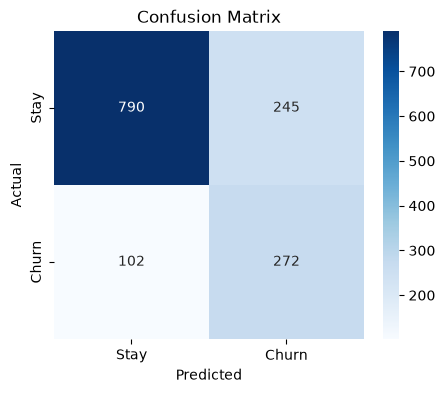

In [7]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("=== Baseline (guess everyone stays) ===")
print(f"Accuracy: {1 - y_test.mean():.2%}\n")

print("=== Your XGBoost model ===")
print(classification_report(y_test, y_pred, target_names=["Stay", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# Confusion matrix (pretty)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d",
            cmap="Blues", xticklabels=["Stay", "Churn"], yticklabels=["Stay", "Churn"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

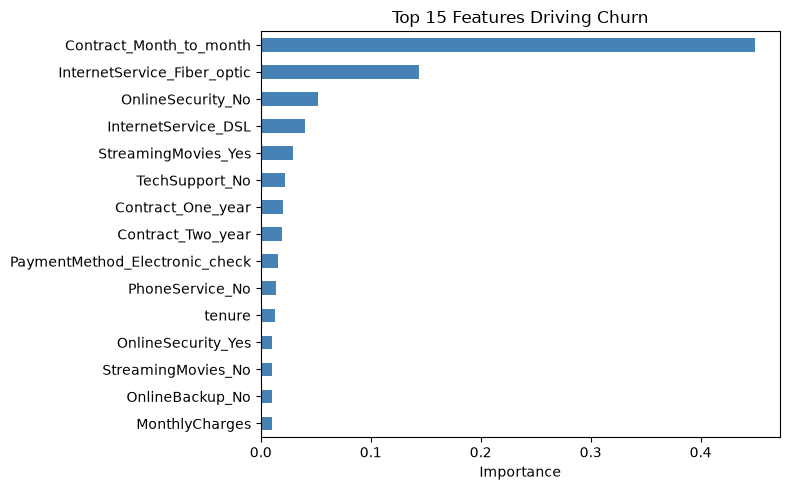

In [8]:
imp = pd.Series(model.feature_importances_, index=X_encoded.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
imp.head(15).sort_values().plot.barh(color="steelblue")
plt.title("Top 15 Features Driving Churn")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [9]:
os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/xgboost_churn_v1.joblib")
joblib.dump(list(X_encoded.columns), "models/feature_columns.joblib")  # 🔑 the blueprint

print("Saved:")
print("  models/xgboost_churn_v1.joblib")
print("  models/feature_columns.joblib")
print("\n🎉 Phase 2 complete — you have a trained, saved, evaluated model.")

Saved:
  models/xgboost_churn_v1.joblib
  models/feature_columns.joblib

🎉 Phase 2 complete — you have a trained, saved, evaluated model.
